Loaded nsdgeneral mask. Total voxels: 15724
Loading beta data...


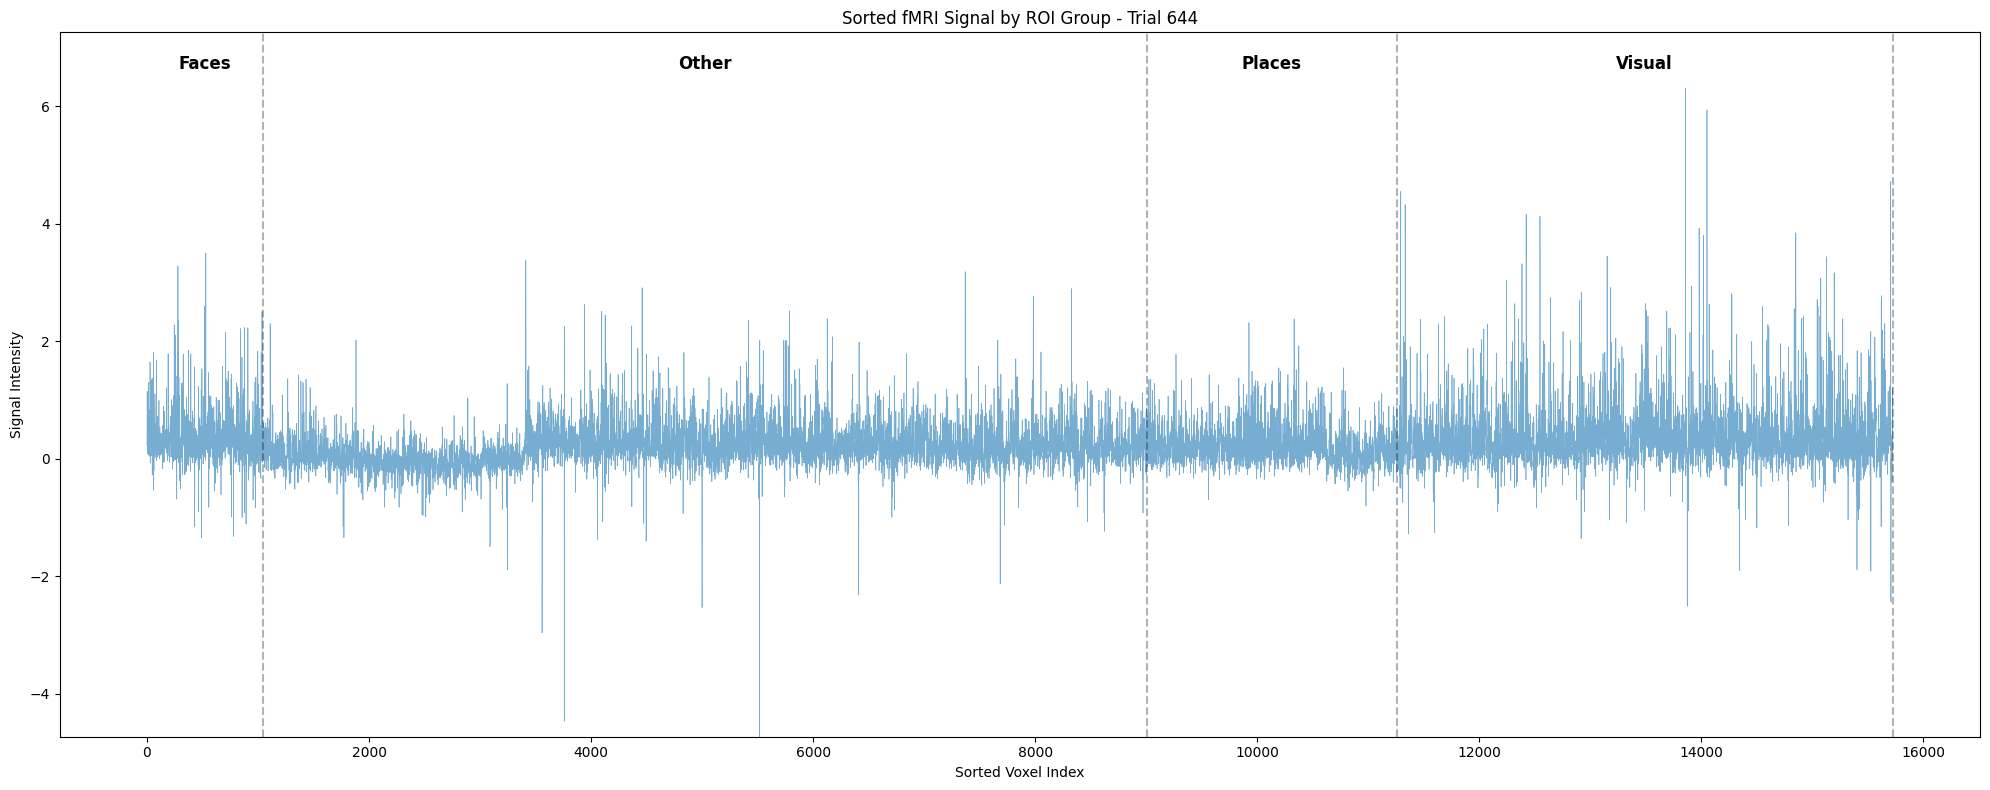

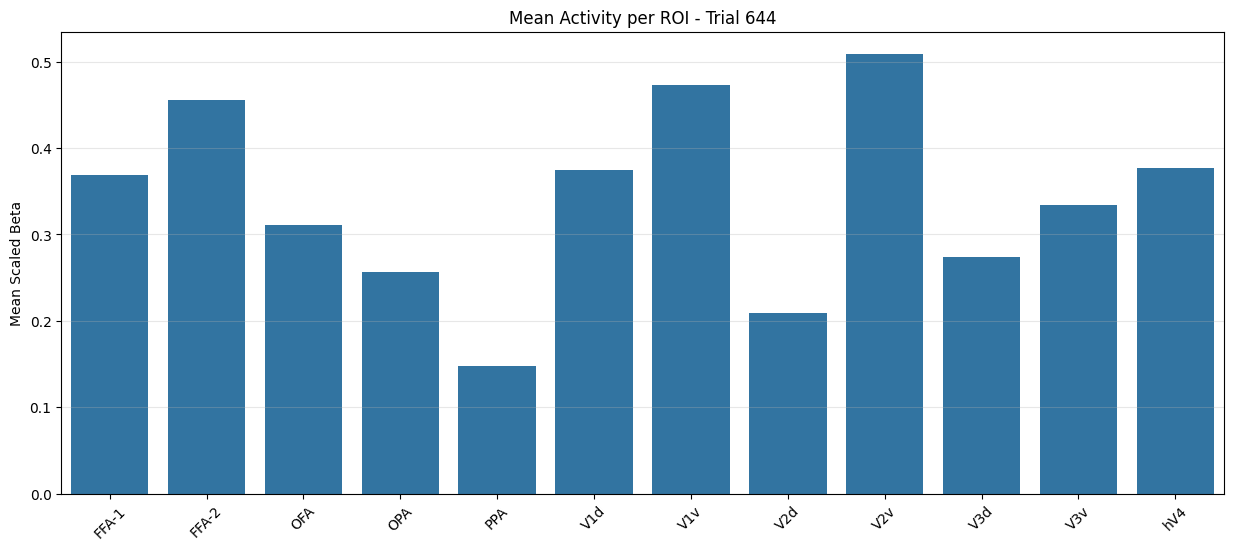

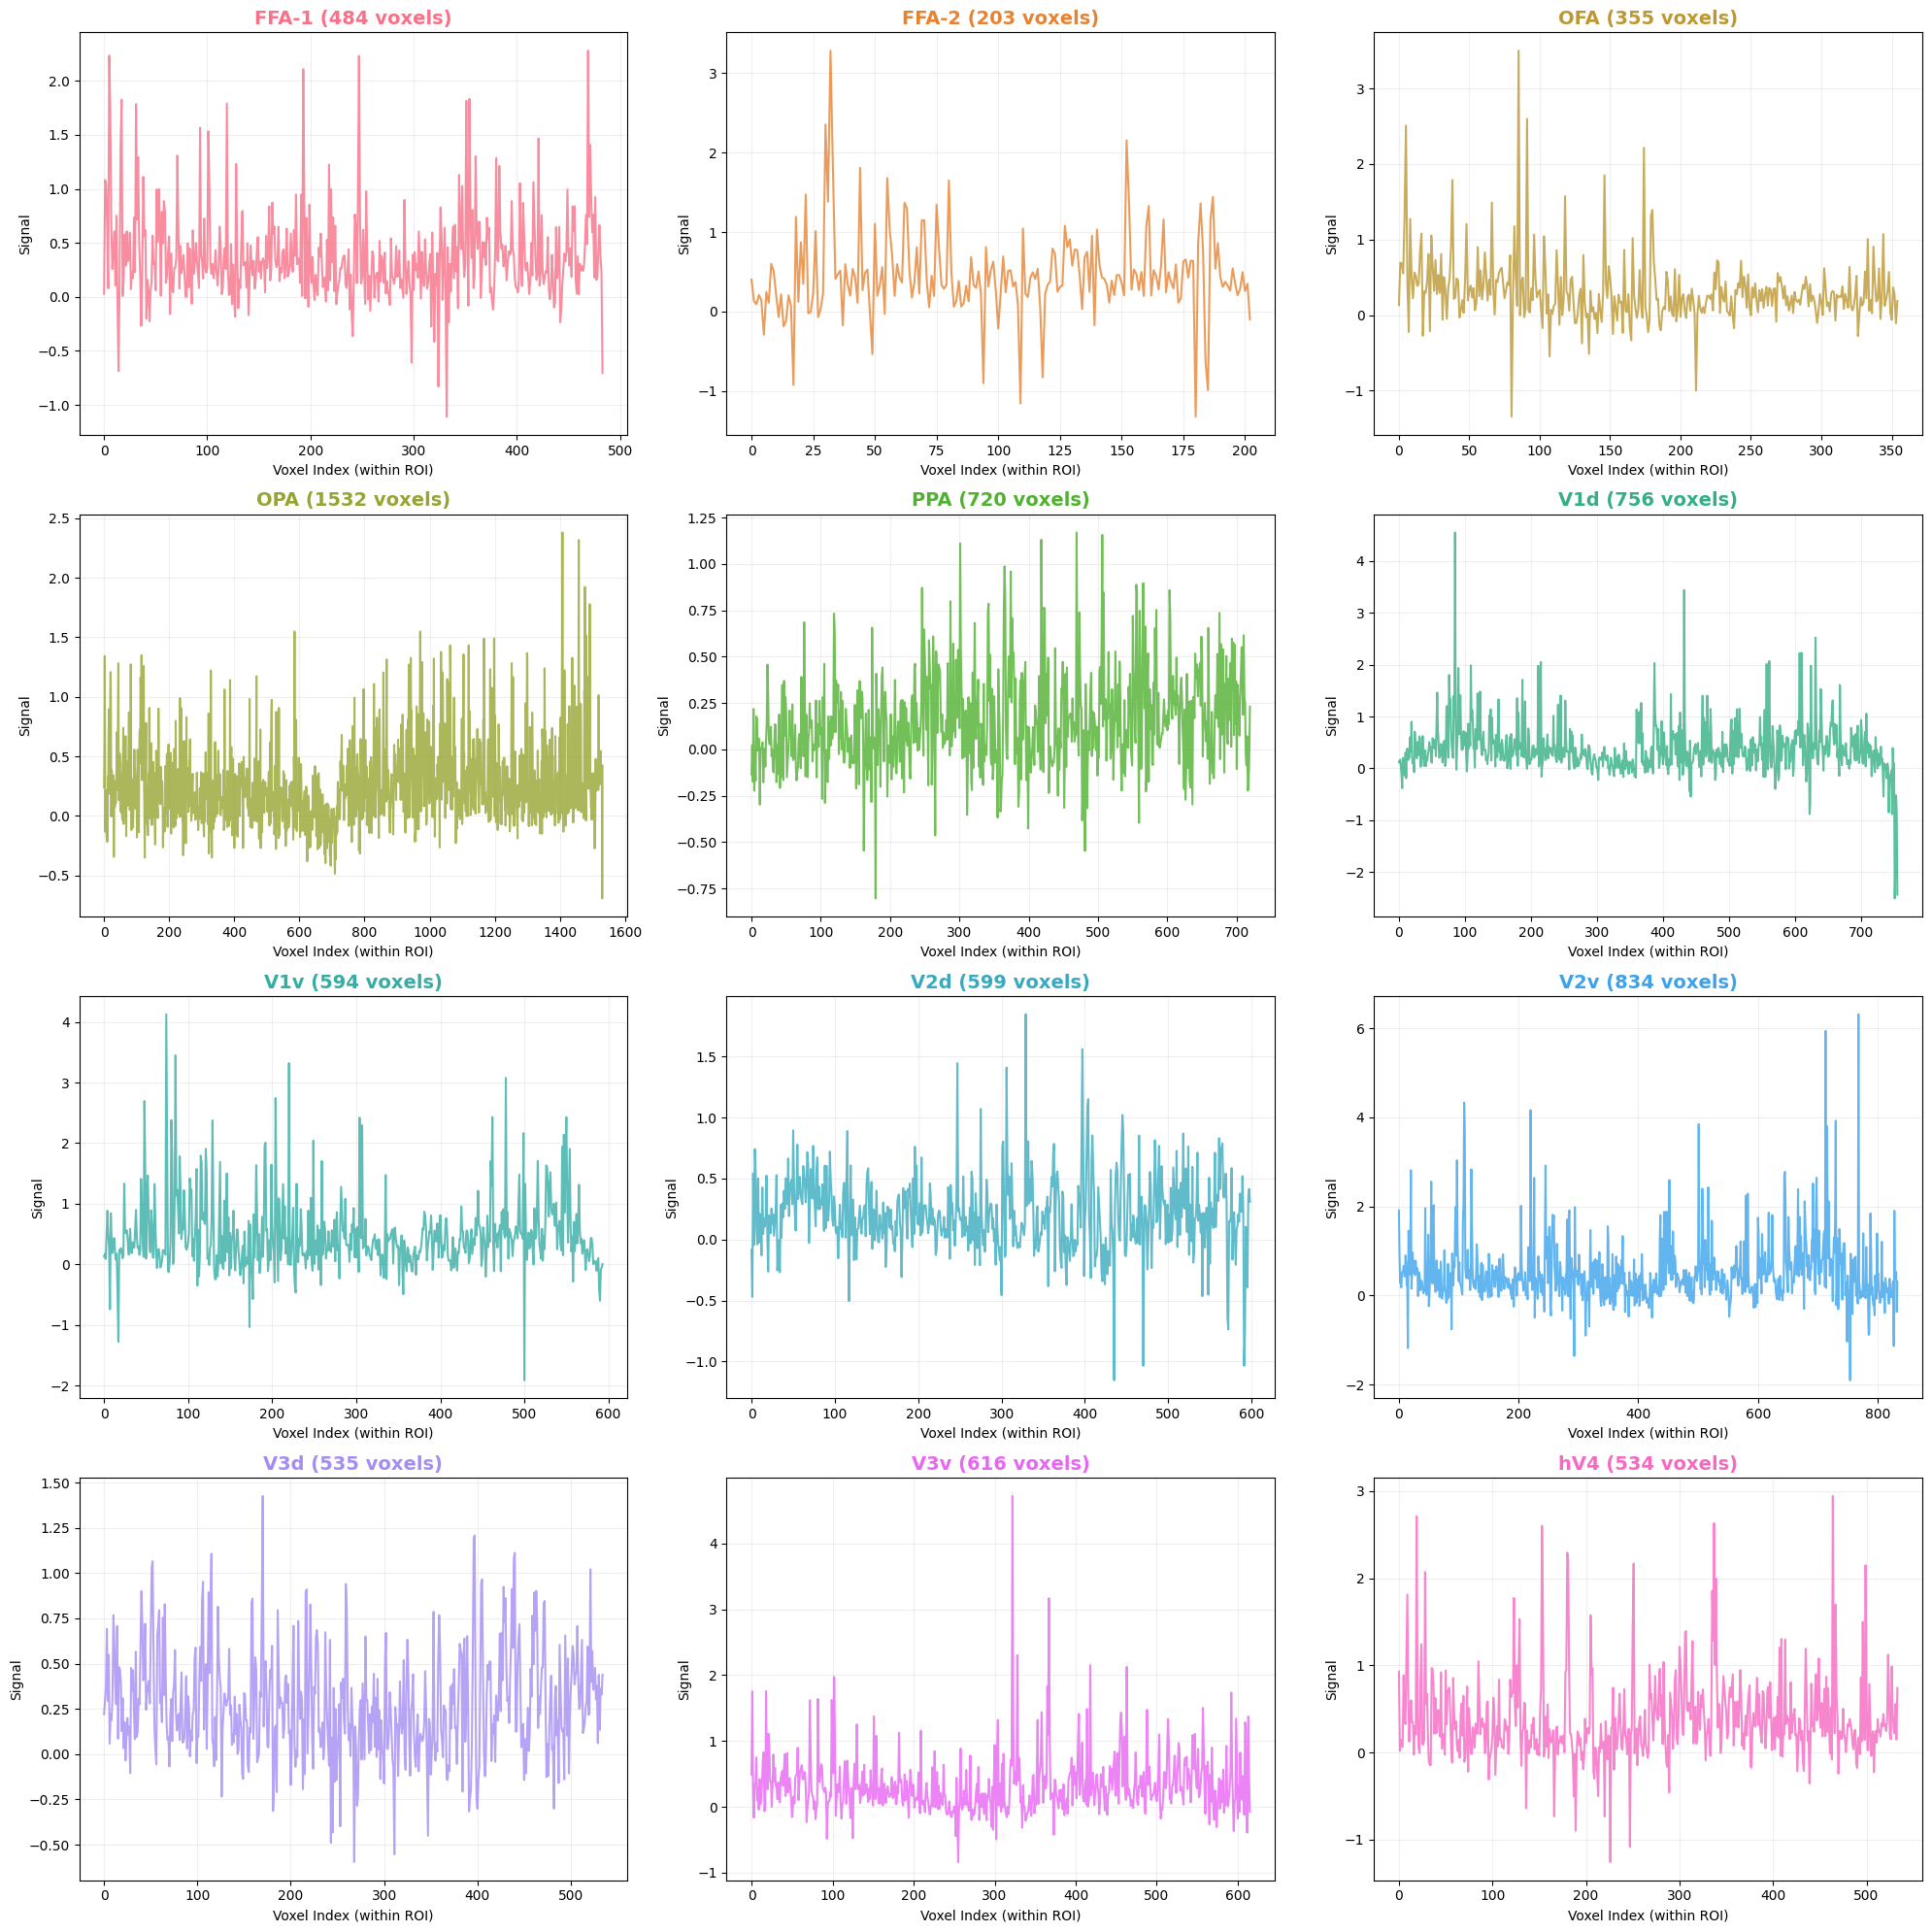

In [4]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
base_path = '/workspace/sdb1/img2fmri/NSD/data'
sub = 1
session = 1

# Paths
roi_dir = os.path.join(base_path, 'nsddata/ppdata/subj{:02d}/func1pt8mm/roi/'.format(sub))
betas_dir = os.path.join(base_path, 'nsddata_betas/ppdata/subj{:02d}/func1pt8mm/betas_fithrf_GLMdenoise_RR/'.format(sub))

# Load nsdgeneral mask (Master Mask)
mask_path = os.path.join(roi_dir, 'nsdgeneral.nii.gz')
mask_img = nib.load(mask_path)
mask_data = mask_img.get_fdata()
general_mask_bool = mask_data > 0
num_voxels = np.sum(general_mask_bool)
print(f"Loaded nsdgeneral mask. Total voxels: {num_voxels}")

# Define ROIs to map (Priority order for visualization grouping)
# We will try to assign each voxel to a primary functional area
roi_files_map = {
    'Visual': 'prf-visualrois.nii.gz', 
    'Faces': 'floc-faces.nii.gz',
    'Places': 'floc-places.nii.gz',
    'Bodies': 'floc-bodies.nii.gz',
    'Words': 'floc-words.nii.gz',
    'Streams': 'streams.nii.gz'
}

# ROI Label definitions (Mapping integer ID to Name)
# Ideally this should be read from .ctab or .txt files, but hardcoding common ones for visualization
visual_labels = {1: 'V1v', 2: 'V1d', 3: 'V2v', 4: 'V2d', 5: 'V3v', 6: 'V3d', 7: 'hV4'}
face_labels = {1: 'OFA', 2: 'FFA-1', 3: 'FFA-2', 4: 'mTL-faces', 5: 'aTL-faces'} # Simplified lookup
place_labels = {1: 'OPA', 2: 'PPA', 3: 'RSC'} 

# Store voxel assignments
# Initialize with 'Unassigned' or 'General'
voxel_labels = np.array(['General'] * num_voxels, dtype=object)
voxel_roi_group = np.array(['Other'] * num_voxels, dtype=object)

# Helper to flatten ROI mask
def get_flat_roi(roi_filename):
    p = os.path.join(roi_dir, roi_filename)
    if os.path.exists(p):
        d = nib.load(p).get_fdata()
        # Extract voxels corresponding to nsdgeneral mask
        return d[general_mask_bool]
    return None

# Process Visual ROIs first (usually most granular in visual cortex)
visual_flat = get_flat_roi(roi_files_map['Visual'])
if visual_flat is not None:
    for vid, vname in visual_labels.items():
        mask_idx = visual_flat == vid
        voxel_labels[mask_idx] = vname
        voxel_roi_group[mask_idx] = 'Visual'

# Process Category ROIs (Faces, Places, etc.)
# These might overlap with visual ROIs or each other. We overwrite for specificity or keep first? 
# Let's simply mark them. If a voxel is already V1, it's V1. But typically Faces/Places are higher level.
category_rois = [('Faces', face_labels, 'floc-faces.nii.gz'), ('Places', place_labels, 'floc-places.nii.gz')]

for cat_name, label_map, fname in category_rois:
    flat = get_flat_roi(fname)
    if flat is not None:
        indices = np.where(flat > 0)[0]
        # Only map if currently General or Visual (Higher level function usually trumps retinotopy description for 'what' pathway?)
        # Actually, let's just accept the category label
        for idx in indices:
            val = int(flat[idx])
            if val in label_map:
                lbl = label_map[val]
                voxel_labels[idx] = lbl
                voxel_roi_group[idx] = cat_name

# Load fMRI Data (Betas)
beta_filename = "betas_session{0:02d}.nii.gz".format(session)
beta_path = os.path.join(betas_dir, beta_filename)
if os.path.exists(beta_path):
    print("Loading beta data...")
    beta_img = nib.load(beta_path)
    beta_full = beta_img.get_fdata().astype(np.float32)
    
    # Get flat masked betas: (N_voxels, N_trials)
    # Transpose to get (N_trials, N_voxels) for easier plotting
    betas_flat = beta_full[general_mask_bool].T / 2000.0
    
    # Pick a random trial
    import random
    trial_idx = random.randint(0, betas_flat.shape[0]-1)
    signal = betas_flat[trial_idx]
    
    # SORTING for Visualization
    # We want to group voxels by their ROI Label for the plot
    sort_indices = np.argsort(voxel_roi_group)
    sorted_signal = signal[sort_indices]
    sorted_labels = voxel_labels[sort_indices]
    sorted_groups = voxel_roi_group[sort_indices]
    
    # Create Plot
    plt.figure(figsize=(20, 8))
    
    # Plot the signal
    plt.plot(sorted_signal, alpha=0.6, linewidth=0.5, label='fMRI Signal')
    
    # Annotate Groups
    # Find transitions between groups
    unique_groups = np.unique(sorted_groups)
    # We need to find the start index of each group in the sorted array
    
    for grp in unique_groups:
        grp_indices = np.where(sorted_groups == grp)[0]
        if len(grp_indices) > 0:
            start = grp_indices[0]
            end = grp_indices[-1]
            mid = (start + end) / 2
            
            # Draw vertical line separator
            plt.axvline(x=end, color='k', linestyle='--', alpha=0.3)
            
            # Add Text Label
            plt.text(mid, np.max(sorted_signal)*1.05, grp, ha='center', fontsize=12, fontweight='bold')

    plt.title(f"Sorted fMRI Signal by ROI Group - Trial {trial_idx}")
    plt.xlabel("Sorted Voxel Index")
    plt.ylabel("Signal Intensity")
    plt.ylim(np.min(sorted_signal), np.max(sorted_signal)*1.15)
    plt.tight_layout()
    plt.show()
    
    # Detailed Bar Plot for Mean Activity per ROI
    # Group by specific labels (V1, V2, OFA, etc.)
    unique_labels = np.unique(sorted_labels)
    roi_means = []
    roi_names = []
    unique_sorted = []
    
    for lbl in unique_labels:
        if lbl != 'General': # skip general/unassigned for clearer plot
            vals = signal[voxel_labels == lbl]
            if len(vals) > 0:
                roi_means.append(np.mean(vals))
                roi_names.append(lbl)
                unique_sorted.append(lbl)
                
    plt.figure(figsize=(15, 6))
    sns.barplot(x=roi_names, y=roi_means)
    plt.title(f"Mean Activity per ROI - Trial {trial_idx}")
    plt.xticks(rotation=45)
    plt.ylabel("Mean Scaled Beta")
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
    # --- NEW: Individual Plots per ROI ---
    # Filter out 'General' and 'Unassigned' for detailed view
    rois_to_plot = unique_sorted
    num_rois = len(rois_to_plot)
    cols = 3
    rows = (num_rois + cols - 1) // cols
    
    plt.figure(figsize=(20, 5 * rows))
    # Generate distinct colors
    palette = sns.color_palette("husl", num_rois)
    
    for i, roi_name in enumerate(rois_to_plot):
        plt.subplot(rows, cols, i + 1)
        
        # Get signal for this ROI
        roi_indices = np.where(voxel_labels == roi_name)[0]
        roi_signal = signal[roi_indices]
        
        # Plot
        plt.plot(roi_signal, color=palette[i], alpha=0.8)
        plt.title(f"{roi_name} ({len(roi_signal)} voxels)", fontsize=14, fontweight='bold', color=palette[i])
        plt.xlabel("Voxel Index (within ROI)")
        plt.ylabel("Signal")
        plt.grid(True, alpha=0.2)
        
    plt.tight_layout()
    plt.show()
    
else:
    print("Beta file not found.")

ROIs for FC Matrix: ['FFA-1', 'FFA-2', 'OFA', 'OPA', 'PPA', 'V1d', 'V1v', 'V2d', 'V2v', 'V3d', 'V3v', 'hV4']


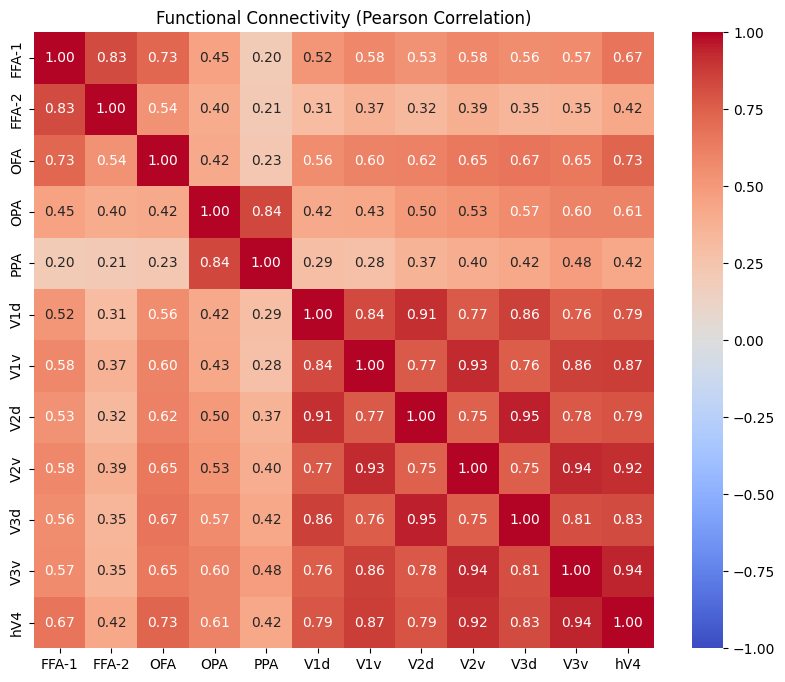

In [8]:

# --- Functional Connectivity (FC) Analysis ---

# 1. Define ROIs to include in FC Matrix
# Filter out 'General' and 'Unassigned'
fc_rois = [lbl for lbl in np.unique(voxel_labels) if lbl not in ['General', 'Unassigned']]
print(f"ROIs for FC Matrix: {fc_rois}")

if len(fc_rois) > 1:
    # 2. Extract Mean Time Series for each ROI
    roi_time_series = []
    for roi in fc_rois:
        roi_indices = np.where(voxel_labels == roi)[0]
        roi_betas = betas_flat[:, roi_indices] # (N_trials, N_voxels)
        roi_mean_ts = np.mean(roi_betas, axis=1) # (N_trials,)
        roi_time_series.append(roi_mean_ts)
    
    roi_time_series = np.array(roi_time_series)
    
    # 3. Compute Correlation Matrix
    fc_matrix = np.corrcoef(roi_time_series)
    
    # 4. Visualization
    plt.figure(figsize=(10, 8))
    sns.heatmap(fc_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
                xticklabels=fc_rois, yticklabels=fc_rois, vmin=-1, vmax=1)
    plt.title("Functional Connectivity (Pearson Correlation)")
    plt.show()
else:
    print("Not enough specific ROIs for FC analysis.")


In [ ]:
!python3 SynBrain/src/physio/train_physio_vae.py --physio_mode physical --num_epochs 1 --batch_size 4 --save_path /workspace/sdb1/img2fmri/BrainSyn --data_path /workspace/sdb1/img2fmri/NSD/data/nsd